# GRE Admissions Forecasting Success with Data

- Dataset: https://www.kaggle.com/code/abdmental01/gre-admissions-forecasting-success-with-data/notebook 

*** Notes **

- when working with Regression problem use activation as *linear*

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("c:/Desktop/Desktop/Microsoft_AI_Engineering/deep_learning/dataset/Admission_Predict.csv")

df

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65
...,...,...,...,...,...,...,...,...,...
395,396,324,110,3,3.5,3.5,9.04,1,0.82
396,397,325,107,3,3.0,3.5,9.11,1,0.84
397,398,330,116,4,5.0,4.5,9.45,1,0.91
398,399,312,103,3,3.5,4.0,8.78,0,0.67


In [ ]:
df.info()

# no null values + no object dtype

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         400 non-null    int64  
 1   GRE Score          400 non-null    int64  
 2   TOEFL Score        400 non-null    int64  
 3   University Rating  400 non-null    int64  
 4   SOP                400 non-null    float64
 5   LOR                400 non-null    float64
 6   CGPA               400 non-null    float64
 7   Research           400 non-null    int64  
 8   Chance of Admit    400 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 28.3 KB


In [5]:
df.drop(columns=['Serial No.'], inplace = True)

In [6]:
df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [11]:
X = df.iloc[:, 0:7]
y = df.iloc[:, -1]

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=1)


- MinMaxScaler from scikit-learn defaults to a range of [0, 1].

In [18]:
# Why MinMaxScaler is used here becoz for each column we have a upper and lower bound values. Eg. We know GRE Score won't be above 340, ~TOFEL above 120 etc

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
X_train_scaled # each value is scaled upto a fix range 0-1 

array([[0.22      , 0.17857143, 0.25      , ..., 0.42857143, 0.25      ,
        1.        ],
       [0.88      , 0.96428571, 1.        , ..., 0.85714286, 0.91911765,
        1.        ],
       [0.3       , 0.71428571, 0.5       , ..., 0.57142857, 0.53308824,
        0.        ],
       ...,
       [0.7       , 0.53571429, 0.5       , ..., 0.57142857, 0.70220588,
        1.        ],
       [0.72      , 0.67857143, 1.        , ..., 0.71428571, 0.74632353,
        1.        ],
       [0.2       , 0.46428571, 0.        , ..., 0.14285714, 0.22058824,
        0.        ]], shape=(320, 7))

# Build a Neural Net

In [25]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [35]:
model = Sequential()

model.add(Dense(7,activation='relu', input_dim=7))     # 1st layer of 7 nodes which accepts 7 inputs
model.add(Dense(7,activation='relu')) 
model.add(Dense(1,activation='linear'))

c:\Desktop\Desktop\Microsoft_AI_Engineering\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120 (480.00 B)

 Trainable params: 120 (480.00 B)

 Non-trainable params: 0 (0.00 B)

In [37]:
model.compile(loss='mean_squared_error', optimizer='Adam')


In [38]:
history = model.fit(X_train_scaled, y_train, epochs=25, validation_split=0.2)

Epoch 1/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - loss: 0.6830 - val_loss: 0.6434
Epoch 2/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.5483 - val_loss: 0.5036
Epoch 3/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4162 - val_loss: 0.3687
Epoch 4/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2921 - val_loss: 0.2321
Epoch 5/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1710 - val_loss: 0.1160
Epoch 6/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0847 - val_loss: 0.0480
Epoch 7/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0374 - val_loss: 0.0241
Epoch 8/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0241 - val_loss: 0.0216
Epoch 9/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0234 - val_loss: 0.0221
Epoch 10/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0223 - val_loss: 0.0199
Epoch 11/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0201 - val_loss: 0.0172
Epoch 12/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0183 - val_loss: 0.0152
E

In [39]:
y_pred = model.predict(X_test_scaled)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


In [40]:
from sklearn.metrics import r2_score

r2_score(y_test,y_pred)

0.6104967853515584

In [ ]:
# There are ways to imporve the model's accuracy

# 1) by incaresing dense layer
# 2) increasing epochs 
# etc

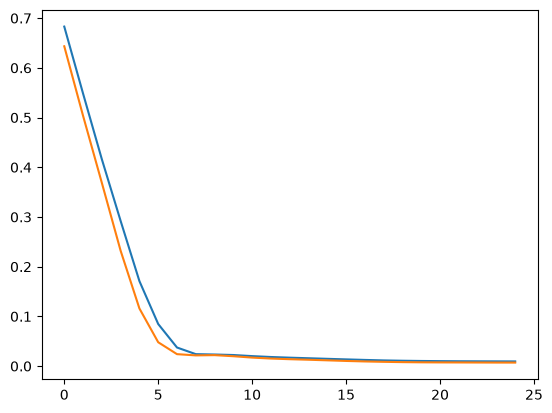

In [42]:
# Plot graphs

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])